# **ICS5110 Part 4 - Model Comparitive Analysis**

## Importing packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
import json

## **Loading the saved model results from Part 3**

In [2]:
results_paths = {
    "Logistic Regression": "results/log_reg_results.json",
    "Random Forest": "results/random_forest_results.json",
    "Support Vector Machine": "results/support_vector_machine_results.json",
    "Gradient Boosting": "results/grad_boost_results.json",
}

model_results = {}
for name, path in results_paths.items():
  print(path)
  with open(path, "rb") as f:
      model_results[name] = json.load(f)

log_reg_results.json
random_forest_results.json
support_vector_machine_results.json
grad_boost_results.json


## **Creating a comprehensive table showcasing the metric results for each model (i.e. accuracy, precision, recall, F1-score)**

In [3]:
log_reg_main_results = model_results['Logistic Regression']['question_4']
random_forest_results = model_results['Random Forest']
support_vector_machine_results = model_results['Support Vector Machine']
grad_boost_results = model_results['Gradient Boosting']

results_dict = {
    'Logistic Regression': log_reg_main_results,
    'Random Forest': random_forest_results,
    'Support Vector Machine': support_vector_machine_results,
    'Gradient Boosting': grad_boost_results
}

In [4]:
def get_metrics(results_data):
  acc = results_data['metric_results']['accuracy']

  macro_avg = results_data['metric_results']['macro avg']
  weighted_avg = results_data['metric_results']['weighted avg']

  macro_prec = macro_avg['precision']
  macro_rec = macro_avg['recall']
  macro_f1 = macro_avg['f1-score']

  weighted_prec = weighted_avg['precision']
  weighted_rec = weighted_avg['recall']
  weighted_f1 = weighted_avg['f1-score']

  neg_class_metrics = results_data['metric_results']['0']
  pos_class_metrics = results_data['metric_results']['1']

  pos_prec = pos_class_metrics['precision']
  pos_rec = pos_class_metrics['recall']
  pos_f1 = pos_class_metrics['f1-score']

  neg_prec = neg_class_metrics['precision']
  neg_rec = neg_class_metrics['recall']
  neg_f1 = neg_class_metrics['f1-score']

  roc_auc = results_data['roc_curve_ovrll']['roc_auc']
  tpr = results_data['roc_curve_ovrll']['tpr']
  fpr = results_data['roc_curve_ovrll']['fpr']

  return {
        'Accuracy': acc,
        'Precision (Macro)': macro_prec,
        'Precision (Weighted)': weighted_prec,
        'Recall (Macro)': macro_rec,
        'Recall (Weighted)': weighted_rec,
        'F1 Score (Macro)': macro_f1,
        'F1 Score (Weighted)': weighted_f1,
        'Precision (Positive Class)': pos_prec,
        'Precision (Negative Class)': neg_prec,
        'Recall (Positive Class)': pos_rec,
        'Recall (Negative Class)': neg_rec,
        'F1 Score (Positive Class)': pos_f1,
        'F1 Score (Negative Class)': neg_f1,
        'ROC AUC': roc_auc,
        'TPR': tpr,
        'FPR': fpr
    }

In [5]:
model_metrics_data = {}

for name, results_path in results_dict.items():
  metrics = get_metrics(results_path)
  model_metrics_data[name] = metrics

# Create a DataFrame from the dictionary of metrics
metrics_df = pd.DataFrame(model_metrics_data).T

metrics_df = metrics_df.drop('TPR', axis=1)
metrics_df = metrics_df.drop('FPR', axis=1)

metrics_df

,Accuracy,Precision (Macro),Precision (Weighted),Recall (Macro),Recall (Weighted),F1 Score (Macro),F1 Score (Weighted),Precision (Positive Class),Precision (Negative Class),Recall (Positive Class),Recall (Negative Class),F1 Score (Positive Class),F1 Score (Negative Class),ROC AUC
Logistic Regression,0.630952,0.494152,0.785993,0.487838,0.630952,0.46276,0.691788,0.111111,0.877193,0.3,0.675676,0.162162,0.763359,0.562162
Random Forest,0.892857,0.746753,0.880334,0.67973,0.892857,0.705493,0.884468,0.571429,0.922078,0.4,0.959459,0.470588,0.940397,0.843919
Support Vector Machine,0.892857,0.628931,0.871743,0.580392,0.892857,0.596154,0.880495,0.333333,0.924528,0.2,0.960784,0.25,0.942308,0.878431
Gradient Boosting,0.904762,0.779605,0.8974,0.72973,0.904762,0.751111,0.900106,0.625,0.934211,0.5,0.959459,0.555556,0.946667,0.836486


## **ROC Curve Plot for all Models**



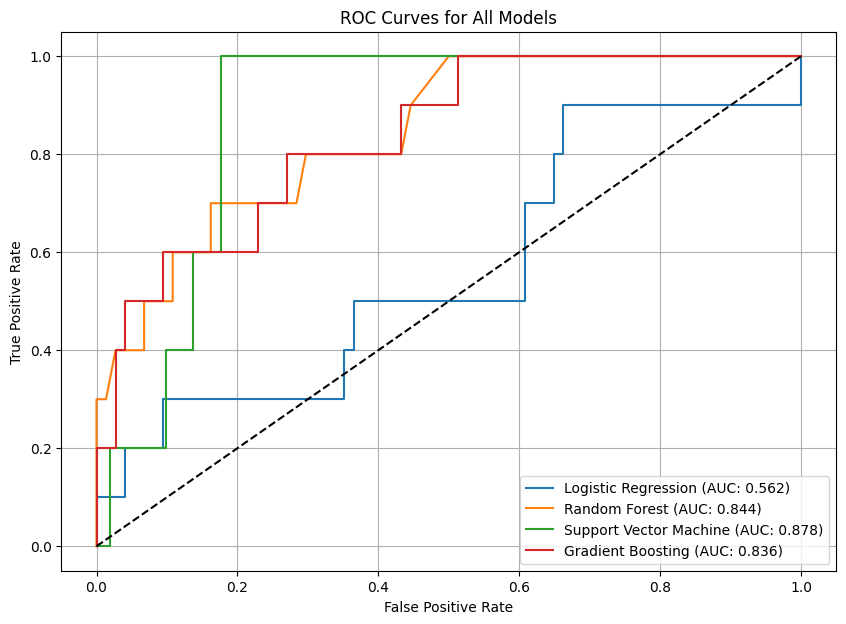

In [6]:
metrics_df = pd.DataFrame(model_metrics_data).T

roc_df = metrics_df[['ROC AUC', 'TPR', 'FPR']]

plt.figure(figsize=(10, 7))

for index, row in roc_df.iterrows():
    plt.plot(row['FPR'], row['TPR'], label=f"{index} (AUC: {row['ROC AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line for random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## **Feature Importance Plot for all Models**



In [7]:
def get_imp_features(results_data):
  feature_imp = results_data['model_feature_importances']

  return feature_imp

In [8]:
model_fi_data = {}

for name, results_path in results_dict.items():
  fi_data = get_imp_features(results_path)
  model_fi_data[name] = fi_data

features_list = {}
features_values = {}

for model_name, features in model_fi_data.items():
  features_list[model_name] = []
  features_values[model_name] = []
  for feature in features:
    features_list[model_name].append(list(feature.values())[0])
    features_values[model_name].append(list(feature.values())[1])

In [9]:
model_fi_data['Gradient Boosting']

[{'Feature': 'num__temperature', 'Importance': 0.13552681131913497},
 {'Feature': 'cat__road_type_main road', 'Importance': 0.13427407815142564},
 {'Feature': 'cat__road_type_residential', 'Importance': 0.08793990702921048},
 {'Feature': 'cat__vehicle_involved_motorcycle',
  'Importance': 0.08327323606297664},
 {'Feature': 'num__time_in_hours', 'Importance': 0.07915281604357007},
 {'Feature': 'num__min_age', 'Importance': 0.07410367801730568},
 {'Feature': 'num__rush_hour', 'Importance': 0.06313478421910967},
 {'Feature': 'cat__weekend_weekday_weekend',
  'Importance': 0.06060961489701834},
 {'Feature': 'num__max_age', 'Importance': 0.04976129830009772},
 {'Feature': 'cat__vehicle_involved_car-motorcycle',
  'Importance': 0.045865589112868754},
 {'Feature': 'num__adult_driver_involved', 'Importance': 0.038693415171300975},
 {'Feature': 'cat__vehicle_involved_van-bus',
  'Importance': 0.03019001659295526},
 {'Feature': 'cat__vehicle_involved_car-car',
  'Importance': 0.02919912667837682

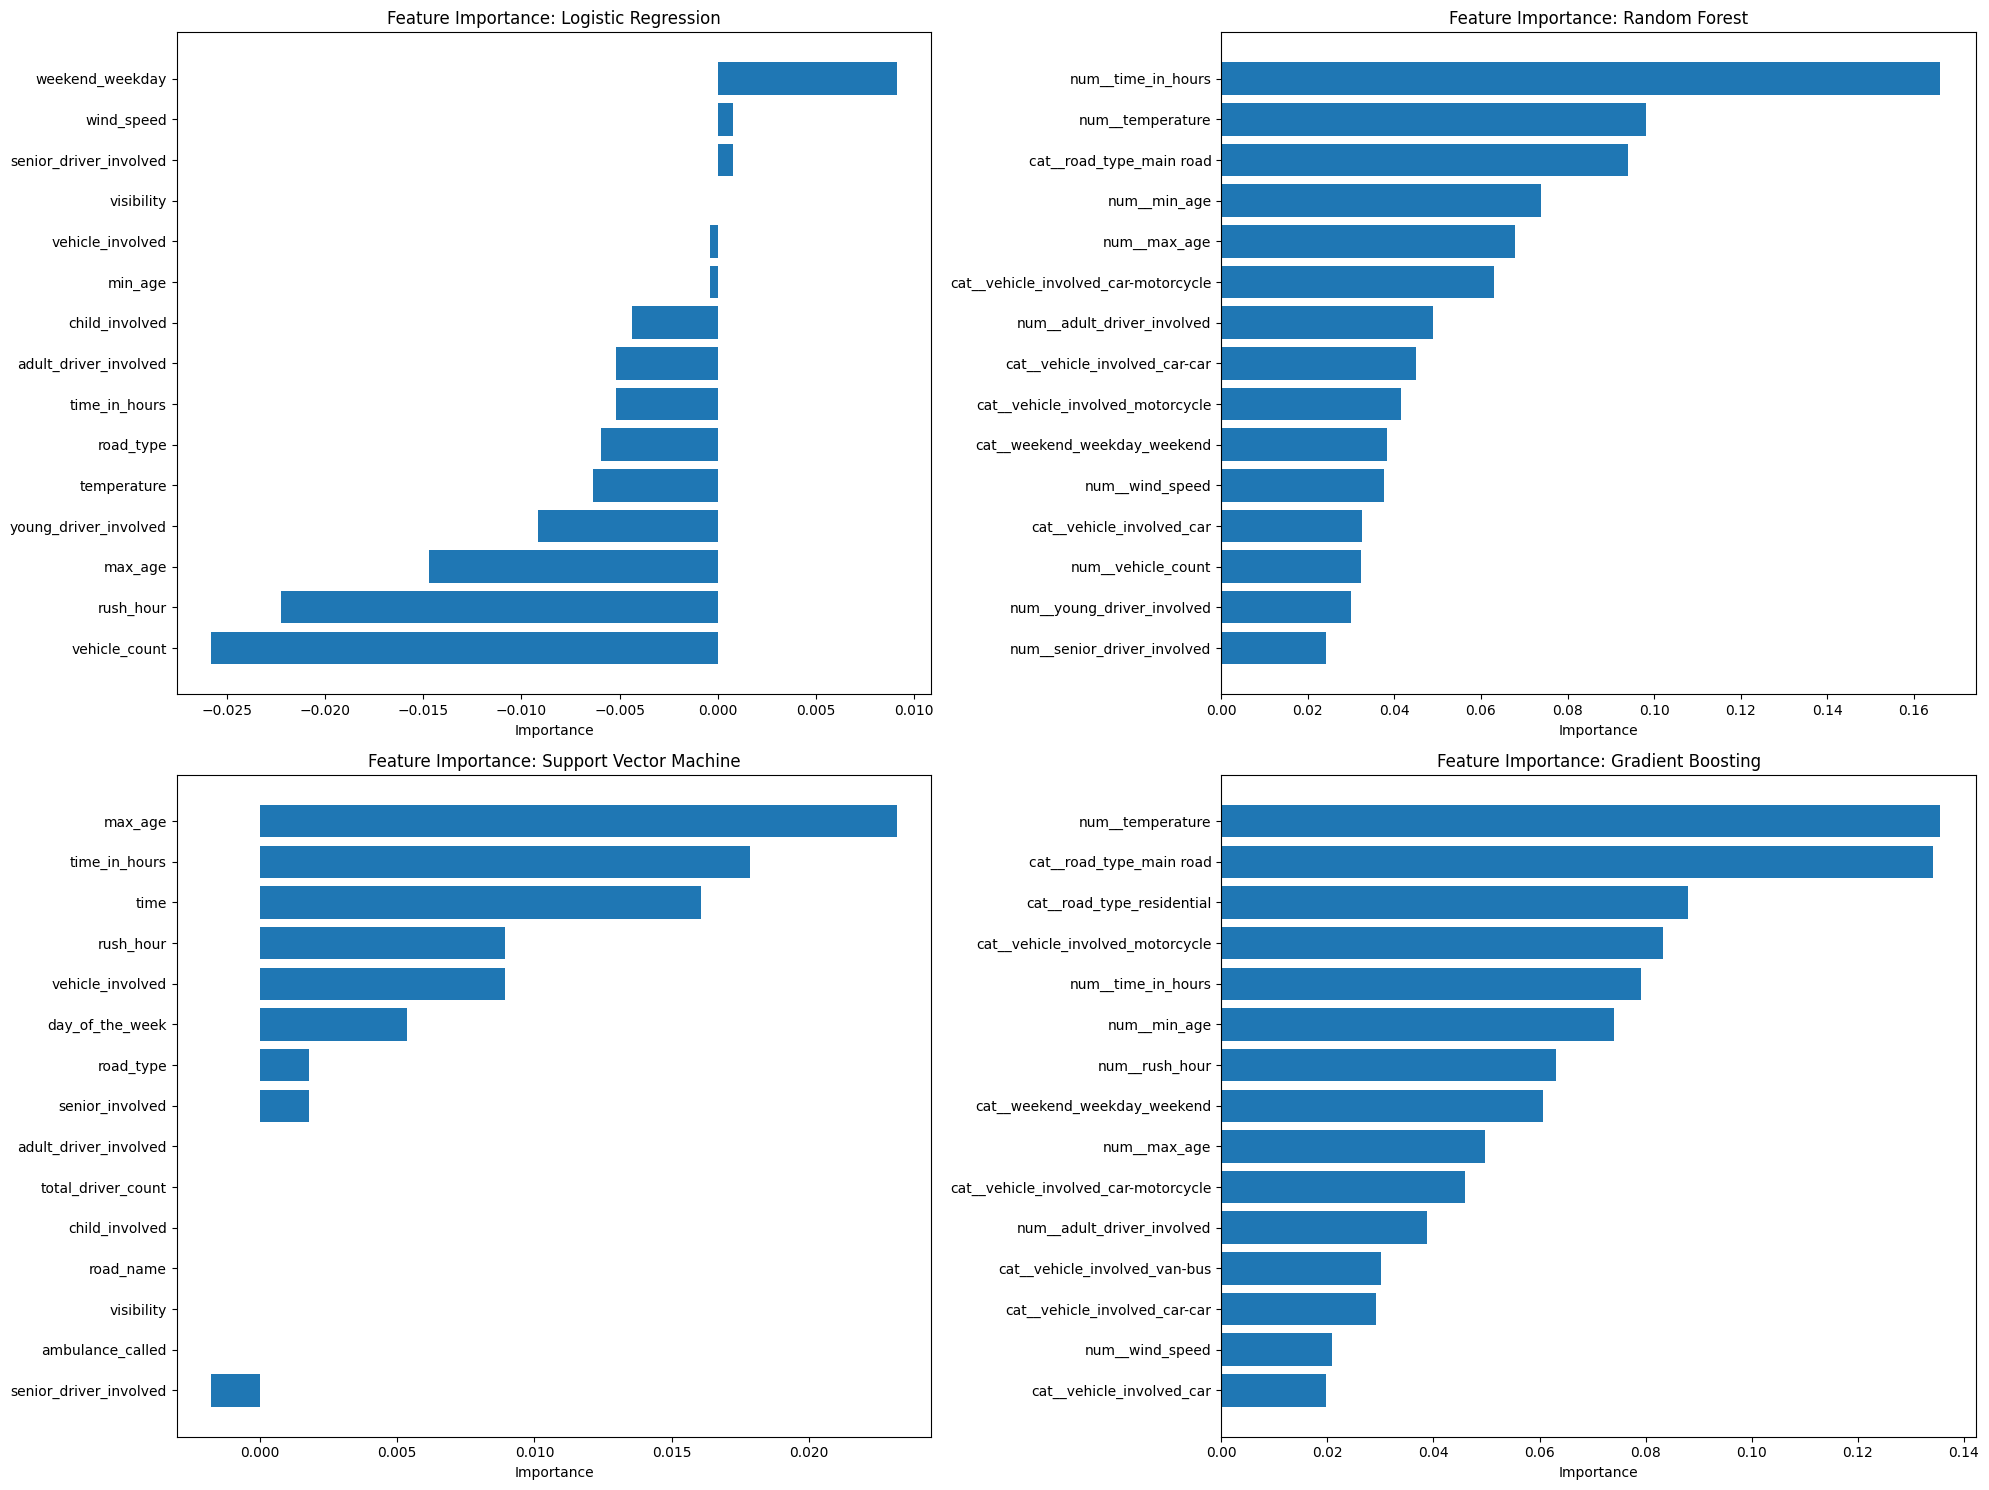

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten()

for i, (model_name, features) in enumerate(model_fi_data.items()):
    # if model_name == "Support Vector Machine":
    #     df_features = pd.DataFrame(features)
    #     if 'Coefficient' in df_features.columns:
    #         df_features['Importance_Abs'] = df_features['Coefficient'].abs()
    #         df_features = df_features.sort_values(by='Importance_Abs', ascending=False)
    #         top_features_df = df_features.head(15)
    #         feature_labels = top_features_df['Feature']
    #         feature_values = top_features_df['Coefficient'] # Plot original coefficient for SVM
    #     elif 'Importance' in df_features.columns:
    #         df_features['Importance_Abs'] = df_features['Importance'].abs()
    #         df_features = df_features.sort_values(by='Importance_Abs', ascending=False)
    #         top_features_df = df_features.head(15)
    #         feature_labels = top_features_df['Feature']
    #         feature_values = top_features_df['Importance']
    #     else:
    #         # Fallback if structure is unexpected, just take first 15 features
    #         feature_labels = [list(f.values())[0] for f in features[:15]]
    #         feature_values = [list(f.values())[1] for f in features[:15]]

    # else:
    df_features = pd.DataFrame(features)
    if 'Importance' in df_features.columns:
        df_features = df_features.sort_values(by='Importance', ascending=False)
        top_features_df = df_features.head(15)
        feature_labels = top_features_df['Feature']
        feature_values = top_features_df['Importance']
    elif 'Coefficient' in df_features.columns:
        df_features['Coefficient_Abs'] = df_features['Coefficient'].abs()
        df_features = df_features.sort_values(by='Coefficient_Abs', ascending=False)
        top_features_df = df_features.head(15)
        feature_labels = top_features_df['Feature']
        feature_values = top_features_df['Coefficient']
    else:
        # Fallback if structure is unexpected
        feature_labels = [list(f.values())[0] for f in features[:15]]
        feature_values = [list(f.values())[1] for f in features[:15]]

    y_pos = np.arange(len(feature_labels))
    axes[i].barh(y_pos, feature_values, align='center')
    axes[i].set_yticks(y_pos)
    axes[i].set_yticklabels(feature_labels)
    axes[i].invert_yaxis()
    axes[i].set_xlabel("Importance")
    axes[i].set_title(f"Feature Importance: {model_name}")

plt.tight_layout()
plt.show()

## **Statistical Significance Testing**

In [11]:
from mlxtend.evaluate import mcnemar_table, mcnemar

def highlight_diff_only(data):
    # Create a mask of empty strings (no style)
    mask = pd.DataFrame('', index=data.index, columns=data.columns)

    for row in data.index:
        for col in data.columns:
            if row != col:
                if data.loc[row, col] < 0.05:
                    mask.loc[row, col] = 'background-color: #00FF00'
                else:
                    mask.loc[row, col] = 'background-color: transparent'
            else:
                mask.loc[row, col] = 'color: grey'

    return mask

def compute_mcnemar(y_true, y_pred_a, y_pred_b):
    table = mcnemar_table(y_target=np.array(y_true),
                          y_model1=np.array(y_pred_a),
                          y_model2=np.array(y_pred_b))

    chi2, p = mcnemar(ary=table, corrected=True)
    return float(chi2), float(p)

# Initialising a common y_true variable as SVM used a smaller test set (20%) compared to the rest of the models (30%)

# Convert lists to pandas Series to enable .index and .intersection
y_test_lr_series = pd.Series(log_reg_main_results['actual'])
y_test_fr_series = pd.Series(random_forest_results['actual'])
y_test_svm_series = pd.Series(support_vector_machine_results['actual'])
y_test_gb_series = pd.Series(grad_boost_results['actual'])

common_idx = (
    y_test_lr_series.index
    .intersection(y_test_fr_series.index)
    .intersection(y_test_svm_series.index)
    .intersection(y_test_gb_series.index)
)

y_true = y_test_lr_series.loc[common_idx]

# Loading predictions for all models
model_y_preds = {}
for model, results_path_data in results_dict.items():
    # Convert the predictions list to a pandas Series
    predictions_series = pd.Series(results_path_data["predictions"])
    # Filter using common_idx
    model_y_preds[model] = predictions_series.loc[common_idx]

model_names = list(model_y_preds.keys())
p_matrix = pd.DataFrame(index=model_names, columns=model_names)

for model_a_name, model_a_y in model_y_preds.items():
    for model_b_name, model_b_y in model_y_preds.items():
        if model_a_name == model_b_name:
            p_matrix.loc[model_a_name, model_b_name] = 1.0
            continue
        chi2, p = compute_mcnemar(y_true, model_a_y, model_b_y)
        p_matrix.loc[model_a_name, model_b_name] = p

p_matrix.style.apply(highlight_diff_only, axis=None).format("{:.4f}").set_caption("P-Values (Green = Significant)")

/usr/local/lib/python3.12/dist-packages/mlxtend/evaluate/mcnemar.py:209: RuntimeWarning: divide by zero encountered in scalar divide
  chi2 = (abs(ary[0, 1] - ary[1, 0]) - 1.0) ** 2 / float(n)


,Logistic Regression,Random Forest,Support Vector Machine,Gradient Boosting
Logistic Regression,1.0000,0.0036,0.0339,0.0036
Random Forest,0.0036,1.0000,0.4497,0.0000
Support Vector Machine,0.0339,0.4497,1.0000,0.4497
Gradient Boosting,0.0036,0.0000,0.4497,1.0000


In [ ]:
from mlxtend.evaluate import mcnemar_table, mcnemar

def highlight_diff_only(data):
    # Create a mask of empty strings (no style)
    mask = pd.DataFrame('', index=data.index, columns=data.columns)

    for row in data.index:
        for col in data.columns:
            if row != col:
                if data.loc[row, col] < 0.05:
                    mask.loc[row, col] = 'background-color: green'
                else:
                    mask.loc[row, col] = 'background-color: transparent'
            else:
                mask.loc[row, col] = 'color: grey'

    return mask

def compute_mcnemar(y_true, y_pred_a, y_pred_b):
    table = mcnemar_table(y_target=np.array(y_true),
                          y_model1=np.array(y_pred_a),
                          y_model2=np.array(y_pred_b))

    chi2, p = mcnemar(ary=table, corrected=True)
    return float(chi2), float(p)

# Initialising a common y_true variable as SVM used a smaller test set (20%) compared to the rest of the models (30%)

#y_test_lr = log_reg_main_results['actual']
#y_test_fr = random_forest_results['actual']
#y_test_svm = support_vector_machine_results['actual']
#y_test_gb = grad_boost_results['actual']

y_true = log_reg_main_results['actual']

# Loading predictions for all models except SVM since it was trained for a different use case
model_y_preds = {model: results_path["predictions"] for model, results_path in results_dict.items() if model != 'Support Vector Machine'}

model_names = list(model_y_preds.keys())
p_matrix = pd.DataFrame(index=model_names, columns=model_names)

for model_a_name, model_a_y in model_y_preds.items():
    for model_b_name, model_b_y in model_y_preds.items():
        if model_a_name == model_b_name:
            p_matrix.loc[model_a_name, model_b_name] = 1.0
            continue
        chi2, p = compute_mcnemar(y_true, model_a_y, model_b_y)
        print(f"Model A: {model_a_name}, Model B: {model_b_name}, p-value: {p}")
        p_matrix.loc[model_a_name, model_b_name] = p

p_matrix.style.apply(highlight_diff_only, axis=None).format("{:.4f}").set_caption("P-Values (Green = Significant)")